In [1]:
# ── Imports & connexion ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

SERVER = "DESKTOP-LKG2222"
DATABASE = "FashionEcommerce"

engine = create_engine(
    f"mssql+pyodbc://{SERVER}/{DATABASE}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
    "&TrustServerCertificate=yes"
)

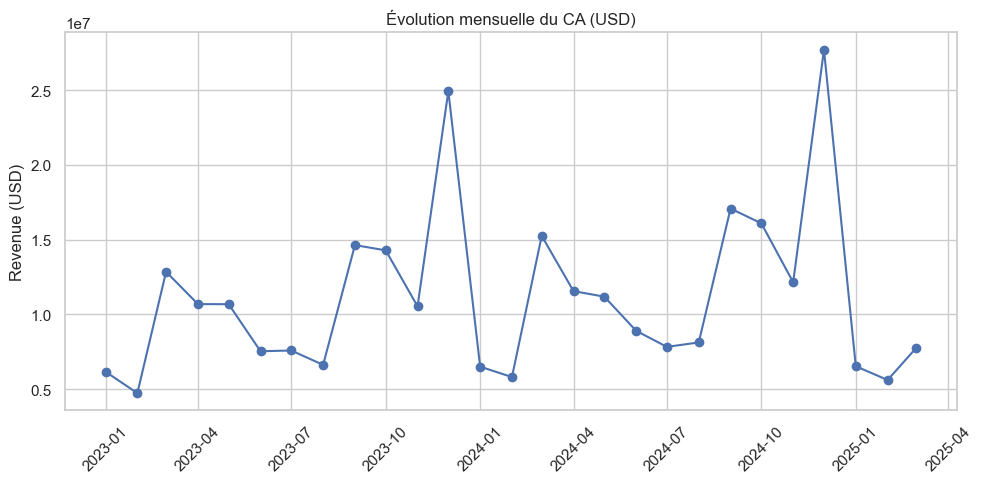

In [2]:
# ── 1. Évolution temporelle du CA (agrégat SQL, pas besoin de charger les lignes brutes) ──
query_monthly = """
SELECT d.[Year], d.[Month], d.Month_Name,
       SUM(f.Line_Total_USD) AS Revenue_USD,
       COUNT(DISTINCT f.Invoice_ID) AS Nb_Orders
FROM warehouse.vw_Fact_Sales_USD f
JOIN warehouse.Dim_Date d ON f.Date_Key = d.Date_Key
WHERE f.Transaction_Type = 'Sale'
GROUP BY d.[Year], d.[Month], d.Month_Name
ORDER BY d.[Year], d.[Month];
"""
monthly = pd.read_sql(query_monthly, engine)
monthly["Period"] = pd.to_datetime(monthly["Year"].astype(str) + "-" + monthly["Month"].astype(str) + "-01")

fig, ax = plt.subplots()
ax.plot(monthly["Period"], monthly["Revenue_USD"], marker="o")
ax.set_title("Évolution mensuelle du CA (USD)")
ax.set_ylabel("Revenue (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

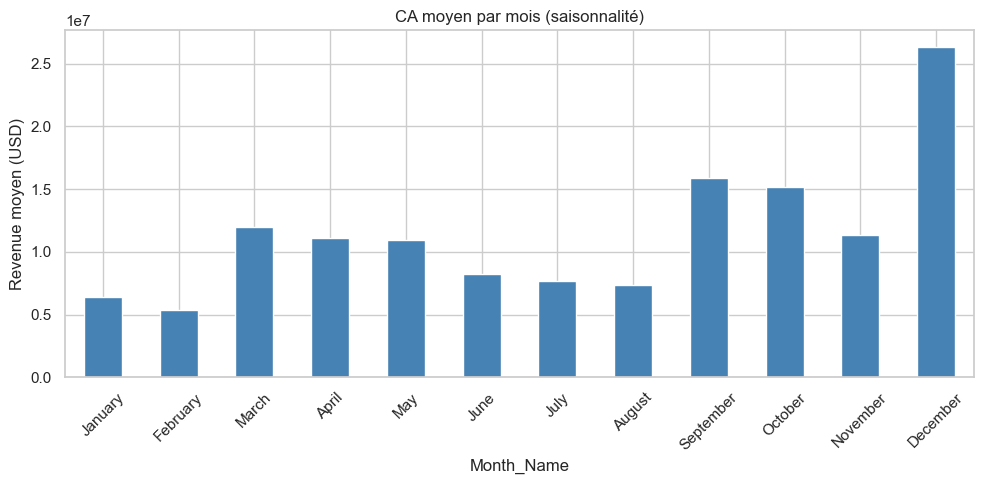

In [3]:
# ── 2. Saisonnalité : CA moyen par mois du calendrier (toutes années confondues) ──
seasonality = monthly.groupby("Month_Name")["Revenue_USD"].mean().reindex([
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
])

fig, ax = plt.subplots()
seasonality.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("CA moyen par mois (saisonnalité)")
ax.set_ylabel("Revenue moyen (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

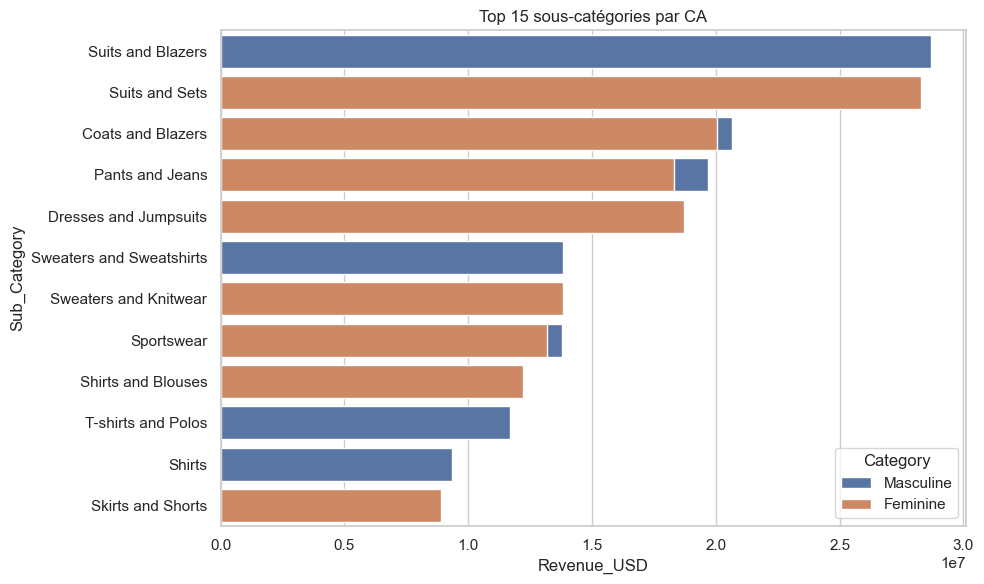

In [4]:
# ── 3. Top catégories / sous-catégories ──
query_category = """
SELECT p.Category, p.Sub_Category,
       SUM(f.Line_Total_USD) AS Revenue_USD,
       SUM(f.Quantity) AS Units_Sold
FROM warehouse.vw_Fact_Sales_USD f
JOIN warehouse.Dim_Product p ON f.Product_Key = p.Product_Key
WHERE f.Transaction_Type = 'Sale'
GROUP BY p.Category, p.Sub_Category
ORDER BY Revenue_USD DESC;
"""
by_category = pd.read_sql(query_category, engine)

top15 = by_category.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top15, y="Sub_Category", x="Revenue_USD", hue="Category", dodge=False, ax=ax)
ax.set_title("Top 15 sous-catégories par CA")
plt.tight_layout()
plt.show()

In [5]:
# ── 4. Échantillon pour distributions / outliers / corrélations ──
# TABLESAMPLE est rapide sur une grosse table ; ~200k lignes suffisent pour une EDA fiable
query_sample = """
SELECT TOP 200000
    Unit_Price_USD, Quantity, Discount, Line_Total_USD, Return_Ratio, Transaction_Type
FROM warehouse.vw_Fact_Sales_USD
WHERE Transaction_Type = 'Sale'
ORDER BY NEWID();
"""
sample = pd.read_sql(query_sample, engine)
sample.describe()

,Unit_Price_USD,Quantity,Discount,Line_Total_USD,Return_Ratio
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.0
mean,51.204810,1.099330,0.126217,49.084842,0.0
std,27.171598,0.394607,0.202680,35.758049,0.0
min,2.540000,1.000000,0.000000,2.160000,0.0
25%,31.860000,1.000000,0.000000,26.320000,0.0
50%,44.820000,1.000000,0.000000,39.916800,0.0
75%,63.980000,1.000000,0.250000,60.480000,0.0
max,160.440000,3.000000,0.600000,477.960000,0.0


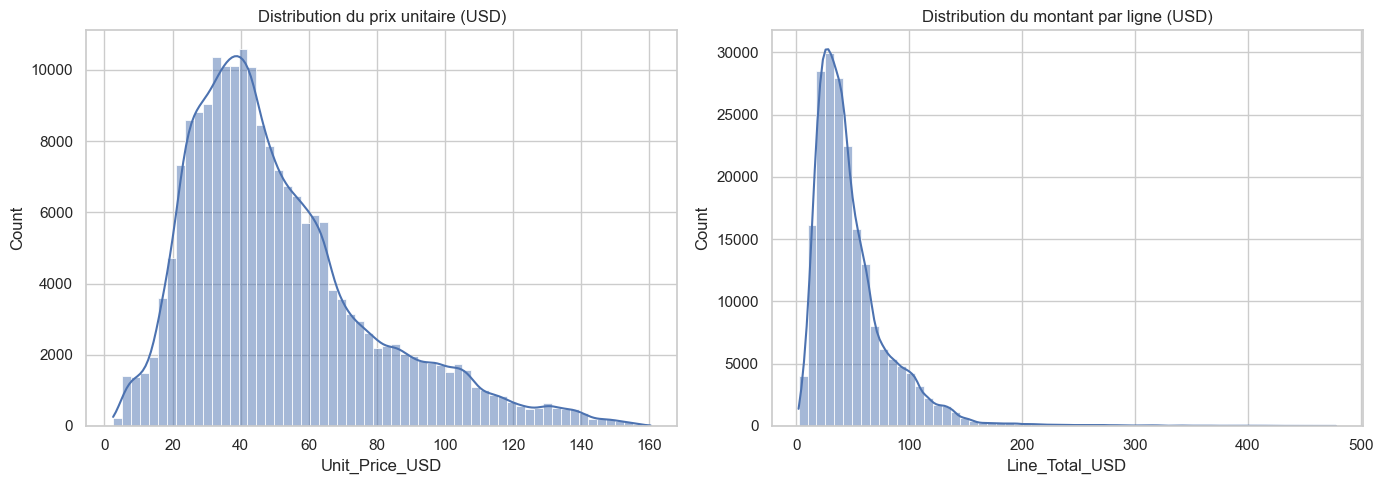

In [6]:
# ── 5. Distribution des prix et du panier ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(sample["Unit_Price_USD"], bins=60, ax=axes[0], kde=True)
axes[0].set_title("Distribution du prix unitaire (USD)")

sns.histplot(sample["Line_Total_USD"], bins=60, ax=axes[1], kde=True)
axes[1].set_title("Distribution du montant par ligne (USD)")

plt.tight_layout()
plt.show()

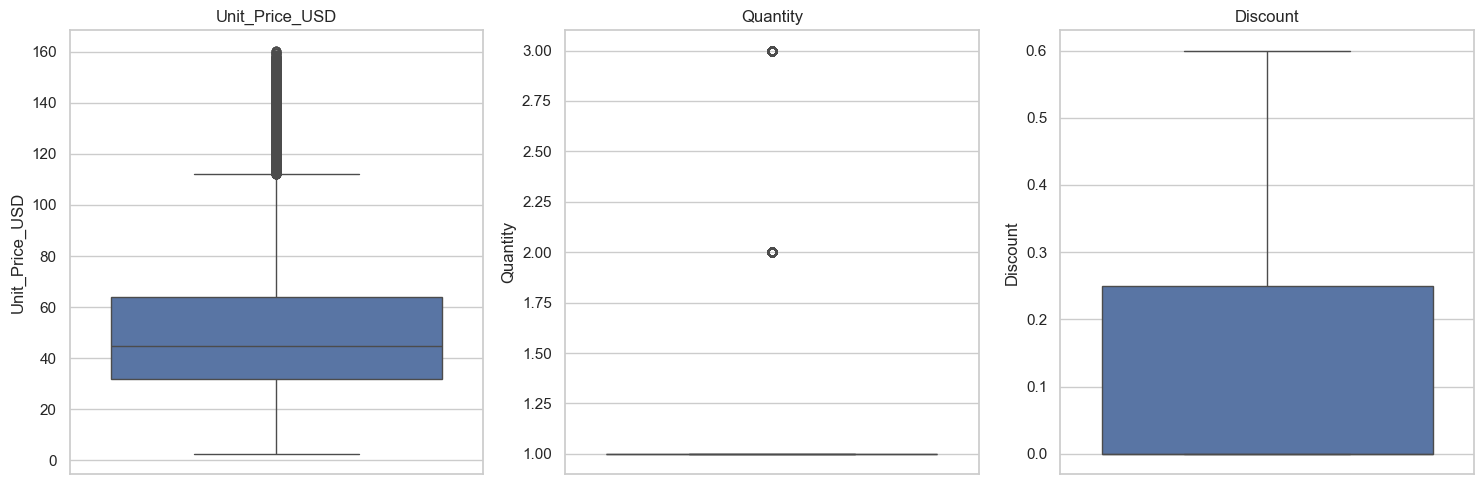

Unit_Price_USD: bornes IQR [-16.32, 112.16] -> 7573 outliers (3.79%)
Quantity: bornes IQR [1.00, 1.00] -> 13241 outliers (6.62%)
Line_Total_USD: bornes IQR [-24.92, 111.72] -> 10626 outliers (5.31%)


In [7]:
# ── 6. Outliers (boxplots) ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=sample["Unit_Price_USD"], ax=axes[0])
axes[0].set_title("Unit_Price_USD")

sns.boxplot(y=sample["Quantity"], ax=axes[1])
axes[1].set_title("Quantity")

sns.boxplot(y=sample["Discount"], ax=axes[2])
axes[2].set_title("Discount")

plt.tight_layout()
plt.show()

# Seuils IQR pour référence chiffrée
for col in ["Unit_Price_USD", "Quantity", "Line_Total_USD"]:
    q1, q3 = sample[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_outliers = ((sample[col] < lower) | (sample[col] > upper)).sum()
    print(f"{col}: bornes IQR [{lower:.2f}, {upper:.2f}] -> {n_outliers} outliers ({100*n_outliers/len(sample):.2f}%)")

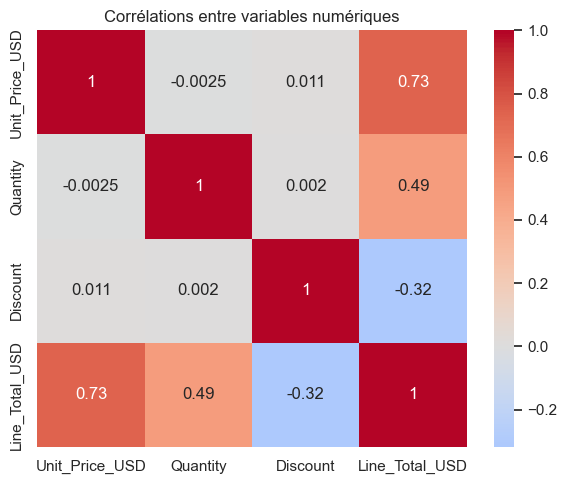

In [8]:
# ── 7. Corrélations ──
corr = sample[["Unit_Price_USD", "Quantity", "Discount", "Line_Total_USD"]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Corrélations entre variables numériques")
plt.tight_layout()
plt.show()

In [9]:
# ── 8. Promotions : les remises augmentent-elles vraiment les ventes ? (prépare la Phase 9) ──
query_promo = """
SELECT
    CASE WHEN Discount > 0 THEN 'Avec remise' ELSE 'Sans remise' END AS Promo_Group,
    COUNT(*) AS Nb_Lines,
    AVG(Quantity * 1.0) AS Avg_Quantity,
    AVG(Line_Total_USD) AS Avg_Line_Total_USD
FROM warehouse.vw_Fact_Sales_USD
WHERE Transaction_Type = 'Sale'
GROUP BY CASE WHEN Discount > 0 THEN 'Avec remise' ELSE 'Sans remise' END;
"""
promo_compare = pd.read_sql(query_promo, engine)
promo_compare

,Promo_Group,Nb_Lines,Avg_Quantity,Avg_Line_Total_USD
0,Avec remise,1788866,1.100212,31.575154
1,Sans remise,4288334,1.100192,56.599601


In [10]:
# ── 9. Test statistique rigoureux : les promos augmentent-elles les ventes ? ──
from scipy import stats

query_promo_detail = """
SELECT
    CASE WHEN Discount > 0 THEN 1 ELSE 0 END AS Has_Promo,
    Quantity,
    Unit_Price_USD * Quantity AS Gross_USD  -- montant AVANT remise, comparaison honnête
FROM warehouse.vw_Fact_Sales_USD
WHERE Transaction_Type = 'Sale'
ORDER BY NEWID()
OFFSET 0 ROWS FETCH NEXT 200000 ROWS ONLY;
"""
promo_detail = pd.read_sql(query_promo_detail, engine)

promo_group = promo_detail[promo_detail["Has_Promo"] == 1]
no_promo_group = promo_detail[promo_detail["Has_Promo"] == 0]

print(f"Avec remise: n={len(promo_group)}, moyenne Quantity={promo_group['Quantity'].mean():.4f}, moyenne Gross_USD={promo_group['Gross_USD'].mean():.2f}")
print(f"Sans remise: n={len(no_promo_group)}, moyenne Quantity={no_promo_group['Quantity'].mean():.4f}, moyenne Gross_USD={no_promo_group['Gross_USD'].mean():.2f}")

# Mann-Whitney U (plus adapté que le t-test ici : Quantity est discret et très asymétrique)
u_stat, p_qty = stats.mannwhitneyu(promo_group["Quantity"], no_promo_group["Quantity"], alternative="two-sided")
print(f"\nQuantity — Mann-Whitney U p-value: {p_qty:.4f}", "-> significatif" if p_qty < 0.05 else "-> PAS significatif")

t_stat, p_gross = stats.ttest_ind(promo_group["Gross_USD"], no_promo_group["Gross_USD"], equal_var=False)
print(f"Gross_USD — t-test p-value: {p_gross:.4f}", "-> significatif" if p_gross < 0.05 else "-> PAS significatif")

# Intervalle de confiance à 95% sur la différence de moyenne (Gross_USD)
diff = promo_group["Gross_USD"].mean() - no_promo_group["Gross_USD"].mean()
se = np.sqrt(promo_group["Gross_USD"].var()/len(promo_group) + no_promo_group["Gross_USD"].var()/len(no_promo_group))
ci_low, ci_high = diff - 1.96*se, diff + 1.96*se
print(f"\nDifférence de moyenne (Gross_USD, avec - sans remise): {diff:.2f} USD, IC95% [{ci_low:.2f}, {ci_high:.2f}]")

Avec remise: n=58911, moyenne Quantity=1.1019, moyenne Gross_USD=55.99
Sans remise: n=141089, moyenne Quantity=1.1008, moyenne Gross_USD=56.58

Quantity — Mann-Whitney U p-value: 0.4869 -> PAS significatif
Gross_USD — t-test p-value: 0.0010 -> significatif

Différence de moyenne (Gross_USD, avec - sans remise): -0.59 USD, IC95% [-0.93, -0.24]
